In [25]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")

In [26]:
N = 50          
BURNIN = 250
N_MEAS = 500
N_TRIALS = 3
B = 0.0
T_CRIT = 2.0 / np.log(1.0 + np.sqrt(2.0))   # ≈ 2.269
 
print(f"T_crit = {T_CRIT:.4f}")
print(f"Lattice: {N}×{N},  burn-in: {BURNIN} sweeps,  measurement: {N_MEAS} sweeps")

T_crit = 2.2692
Lattice: 50×50,  burn-in: 250 sweeps,  measurement: 500 sweeps


In [27]:
lattice = np.random.choice([-1,1], size=(N, N))
print(lattice)
lattice.shape

[[-1 -1 -1 ...  1 -1 -1]
 [-1 -1 -1 ... -1  1  1]
 [-1 -1 -1 ... -1 -1  1]
 ...
 [ 1  1 -1 ...  1  1  1]
 [ 1 -1  1 ... -1 -1  1]
 [-1  1 -1 ... -1 -1 -1]]


(50, 50)

In [28]:
def delta_energy(lattice, i, j, J=1.0, B=0.0):
    Lx, Ly = lattice.shape
    spin = lattice[i, j]

    neighbor_left  = lattice[(i - 1) % Lx, j]
    neighbor_right = lattice[(i + 1) % Lx, j]
    neighbor_up    = lattice[i, (j - 1) % Ly]
    neighbor_down  = lattice[i, (j + 1) % Ly]

    neighbours = neighbor_left + neighbor_right + neighbor_up + neighbor_down

    return 2.0 * spin * (J * neighbours + B)

In [29]:
def metropolis_sweep(lattice, T, J=1.0, B=0.0):
    Lx, Ly = lattice.shape
    beta = 1.0 / T

    for _ in range(Lx * Ly):
        i = np.random.randint(0, Lx)
        j = np.random.randint(0, Ly)
        spin = lattice[i, j]

        neighbours = (
            lattice[(i - 1) % Lx, j] + lattice[(i + 1) % Lx, j] +
            lattice[i, (j - 1) % Ly] + lattice[i, (j + 1) % Ly]
        )
        dE = 2.0 * spin * (J * neighbours + B)

        if dE <= 0 or np.random.random() < np.exp(-beta * dE):
            lattice[i, j] *= -1

    return lattice

In [30]:
def total_energy(lattice, J=1.0, B=0.0):
    E = -J * np.sum(
        lattice * np.roll(lattice, -1, axis=1) +  # right
        lattice * np.roll(lattice, -1, axis=0)     # below
    )
    E -= B * np.sum(lattice)
    return E

In [31]:
def total_magnetization(lattice):
    return np.sum(lattice) / lattice.size

In [32]:
def run_simulation(T, n_burnin, n_meas, N, bias=0.6):
    lattice = np.where(np.random.random((N, N)) < bias, 1, -1).astype(np.int8)
 
    # burn-in
    for _ in range(n_burnin):
        metropolis_sweep(lattice, T)
 
    # measurement
    energies = np.zeros(n_meas)
    mags = np.zeros(n_meas)
    for s in range(n_meas):
        metropolis_sweep(lattice, T)
        energies[s] = total_energy(lattice) / (N * N)
        mags[s]     = abs(total_magnetization(lattice))
 
    return lattice, energies, mags

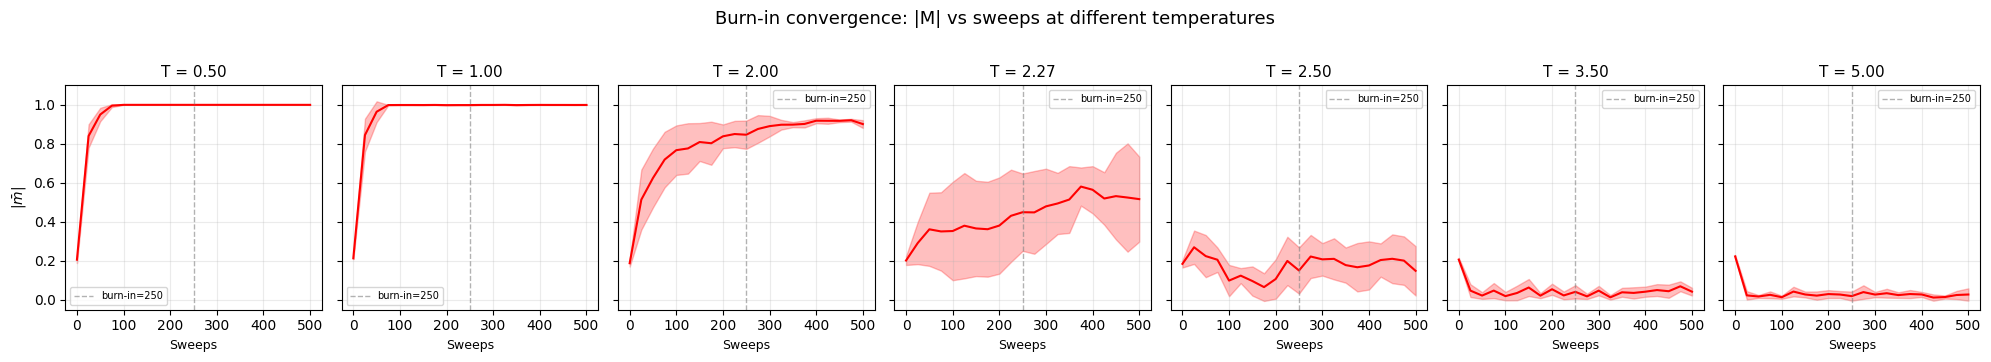

  → saved burnin_convergence.png


In [33]:
burn_temperatures = [0.5, 1.0, 2.0, T_CRIT, 2.5, 3.5, 5.0]
burn_steps        = np.arange(0, 501, 25)
N_BURN_TRIALS     = 5
 
fig, axes = plt.subplots(1, len(burn_temperatures), figsize=(20, 3.5), sharey=True)
cmap_burn = plt.cm.RdPu
 
for idx, T in enumerate(burn_temperatures):
    M_matrix = np.zeros((N_BURN_TRIALS, len(burn_steps)))
 
    for trial in range(N_BURN_TRIALS):
        lattice = np.where(np.random.random((N, N)) < 0.6, 1, -1).astype(np.int8)
        for a, target in enumerate(burn_steps):
            steps_to_do = int(target) - (int(burn_steps[a-1]) if a > 0 else 0)
            for _ in range(steps_to_do):
                metropolis_sweep(lattice, T)
            M_matrix[trial, a] = abs(total_magnetization(lattice))
 
    mean_M = np.mean(M_matrix, axis=0)
    std_M  = np.std(M_matrix,  axis=0)
 
    ax = axes[idx]
    ax.fill_between(burn_steps, mean_M - std_M, mean_M + std_M, alpha=0.25, color='red')
    ax.plot(burn_steps, mean_M, color='red', lw=1.5)
    ax.axvline(x=250, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='burn-in=250')
    ax.set_title(f"T = {T:.2f}", fontsize=11)
    ax.set_xlabel("Sweeps", fontsize=9)
    if idx == 0:
        ax.set_ylabel(r"$|\bar{m}|$", fontsize=10)
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7)
 
fig.suptitle("Burn-in convergence: |M| vs sweeps at different temperatures", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("burnin_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → saved burnin_convergence.png")

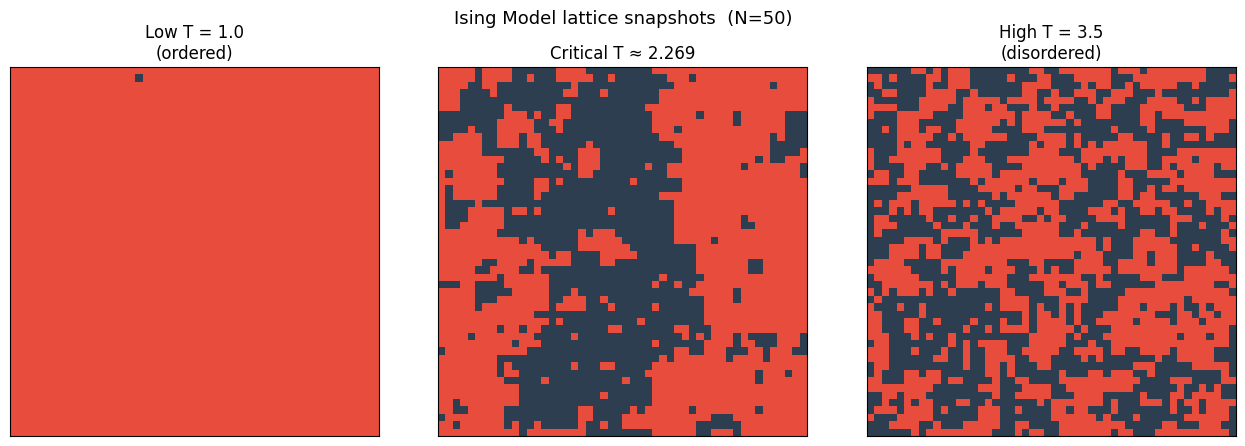

  → saved lattice_snapshots.png


In [34]:
snap_temps  = [1.0, T_CRIT, 3.5]
snap_labels = ["Low T = 1.0\n(ordered)", f"Critical T ≈ {T_CRIT:.3f}", "High T = 3.5\n(disordered)"]
snap_burns  = [50, 250, 50]
 
cmap_lattice = ListedColormap(["#2c3e50", "#e74c3c"])
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
 
for idx, (T, label, bn) in enumerate(zip(snap_temps, snap_labels, snap_burns)):
    lattice = np.where(np.random.random((N, N)) < 0.6, 1, -1).astype(np.int8)
    for _ in range(bn):
        metropolis_sweep(lattice, T)
    axes[idx].imshow(lattice, cmap=cmap_lattice, interpolation='nearest')
    axes[idx].set_title(label, fontsize=12)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])
 
fig.suptitle(f"Ising Model lattice snapshots  (N={N})", fontsize=13)
plt.tight_layout()
plt.savefig("lattice_snapshots.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → saved lattice_snapshots.png")

In [35]:
m = 10   
T_low    = np.linspace(0.5, 2.0,   m,    endpoint=False)
T_critical = np.linspace(2.0, 2.5, 2*m,  endpoint=False)
T_high   = np.linspace(2.5, 4.0,   m)
T_range  = np.concatenate([T_low, T_critical, T_high])
 
mean_M_arr = np.zeros(len(T_range))
std_M_arr  = np.zeros(len(T_range))
mean_E_arr = np.zeros(len(T_range))
std_E_arr  = np.zeros(len(T_range))
mean_Cv    = np.zeros(len(T_range))
mean_chi   = np.zeros(len(T_range))

for k, T in enumerate(T_range):
    print(f"  T = {T:.3f}  ({k+1}/{len(T_range)})", end='\r')
    M_runs = []
    E_runs = []
    Cv_runs = []
    chi_runs = []   
 
    for _ in range(N_TRIALS):
        _, energies, mags = run_simulation(T, BURNIN, N_MEAS, N, bias=0.6)
        M_runs.append(np.mean(mags))
        E_runs.append(np.mean(energies))
        Cv_runs.append((1.0/T)**2 * np.var(energies) * N**2)
        chi_runs.append((1.0/T) * np.var(mags) * N**2)

    mean_M_arr[k] = np.mean(M_runs)
    std_M_arr[k]  = np.std(M_runs)
    mean_E_arr[k] = np.mean(E_runs)
    std_E_arr[k]  = np.std(E_runs)
    mean_Cv[k]    = np.mean(Cv_runs)
    mean_chi[k]   = np.mean(chi_runs)
    
print("\n  Done.")

  T = 4.000  (40/40)
  Done.


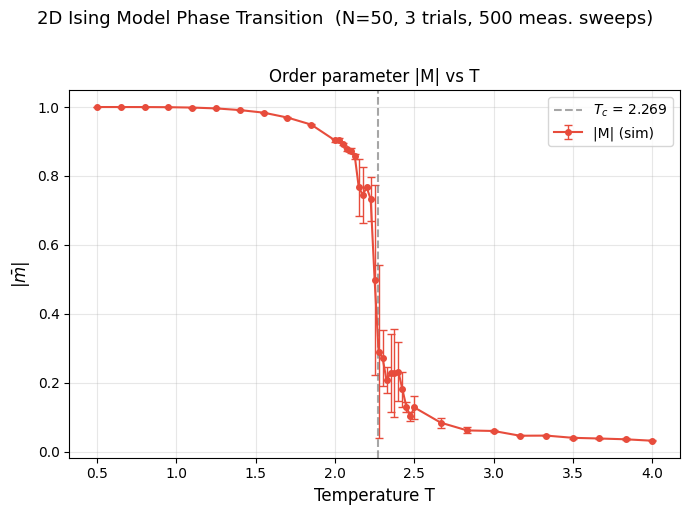

  → saved phase_transition.png


In [36]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# |M| vs T graph
ax.errorbar(T_range, mean_M_arr, yerr=std_M_arr,
            fmt='o-', color='#e74c3c', markersize=4, elinewidth=1, capsize=3, label='|M| (sim)')
ax.axvline(T_CRIT, color='gray', linestyle='--', alpha=0.7, label=f'$T_c$ = {T_CRIT:.3f}')
ax.set_xlabel("Temperature T", fontsize=12)
ax.set_ylabel(r"$|\bar{m}|$", fontsize=12)
ax.set_title("Order parameter |M| vs T", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(f"2D Ising Model Phase Transition  (N={N}, {N_TRIALS} trials, {N_MEAS} meas. sweeps)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("phase_transition.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → saved phase_transition.png")

In [37]:
# saving data
np.savez("ising_data.npz",
         T_range    = T_range,
         mean_M_arr = mean_M_arr,
         std_M_arr  = std_M_arr,
         mean_E_arr = mean_E_arr,
         std_E_arr  = std_E_arr,
         mean_Cv    = mean_Cv,
         mean_chi   = mean_chi)

print("saved ising_data.npz")

saved ising_data.npz


In [38]:
import matplotlib.animation as animation

def make_ising_video_equilibration(T, n_frames, N=50, filename="ising_equil.gif"):
    lattice = np.where(np.random.random((N, N)) < 0.6, 1, -1).astype(np.int8)
    
    
    cmap_lattice = ListedColormap(["#2c3e50", "#e74c3c"])
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(lattice.copy(), cmap=cmap_lattice, interpolation='nearest', vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    title = ax.set_title(f"T = {T:.3f} | Sweep 0", fontsize=12)

    def update(frame):
        metropolis_sweep(lattice, T)
        im.set_data(lattice.copy())
        title.set_text(f"T = {T:.3f} | Sweep {frame + 1}")
        return [im, title]

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=True)
    ani.save(filename, writer="pillow", fps=5)
    plt.close(fig)
    print(f"Saved {filename}")

make_ising_video_equilibration(T=1.0,    n_frames=300, filename="equil_T1.gif")
make_ising_video_equilibration(T=T_CRIT, n_frames=300, filename="equil_critical.gif")
make_ising_video_equilibration(T=3.5,    n_frames=300, filename="equil_T3_5.gif")

Saved equil_T1.gif
Saved equil_critical.gif
Saved equil_T3_5.gif
